# 🤖 Loan Approval Prediction System
## Step 3: Model Training, Evaluation & Comparison

Welcome to the **Model Training Stage** of the Loan Approval Prediction System!

In this notebook, we train, evaluate, and compare four diverse machine learning classification algorithms:
1. **Logistic Regression** (Linear baseline classifier)
2. **Decision Tree Classifier** (Non-linear rule-based tree)
3. **Random Forest Classifier** (Ensemble of bagged decision trees)
4. **XGBoost Classifier** (State-of-the-art gradient boosted trees)

### 🛡️ Core ML Best Practices Followed:
- **No Data Leakage**: Models are trained **strictly on `X_train`**; the test set (`X_test`) is reserved solely for unbiased evaluation.
- **Multiple Metrics**: Accuracy alone can be misleading, so we evaluate **Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrices**.
- **Model Selection & Persistence**: The best-performing model is identified and saved to disk for deployment.

---


In [1]:
import os
import sys
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to sys.path so we can import from src
project_root = os.path.abspath(os.path.join('..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

from src.data_preprocessing import preprocess_data

# Set visual styling for plots
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


### 📁 1. Load Preprocessed Data
We load the preprocessed features and labels using our modular pipeline from `src.data_preprocessing`.
The preprocessing pipeline was fitted solely on training data with an 80/20 stratified split (`random_state=42`).


In [2]:
# Preprocess data using our existing pipeline
X_train, X_test, y_train, y_test, preprocessor, feature_names = preprocess_data()

print(f"X_train shape : {X_train.shape} (80% training instances)")
print(f"X_test shape  : {X_test.shape} (20% unseen test instances)")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape  : {y_test.shape}")
print(f"\nProcessed Features ({len(feature_names)}):")
for i, name in enumerate(feature_names, 1):
    print(f"  {i:2d}. {name}")

X_train shape : (3415, 11) (80% training instances)
X_test shape  : (854, 11) (20% unseen test instances)
y_train shape : (3415,)
y_test shape  : (854,)

Processed Features (11):
   1. num__no_of_dependents
   2. num__income_annum
   3. num__loan_amount
   4. num__loan_term
   5. num__cibil_score
   6. num__residential_assets_value
   7. num__commercial_assets_value
   8. num__luxury_assets_value
   9. num__bank_asset_value
  10. cat__education_Not Graduate
  11. cat__self_employed_Yes


---
## 📖 Understanding Evaluation Metrics (Beginner Guide)

In credit risk and loan approval, different types of errors have different real-world consequences:
* **True Positive (TP)**: Loan was Approved and model predicted Approved.
* **True Negative (TN)**: Loan was Rejected and model predicted Rejected.
* **False Positive (FP - Type I Error)**: Loan was actually high risk (Rejected), but the model incorrectly predicted Approved (bad loan risk for the bank!).
* **False Negative (FN - Type II Error)**: Eligible applicant (Approved), but the model incorrectly predicted Rejected (lost business).

### The 5 Key Metrics:
1. **Accuracy**: Total fraction of correct predictions: $\frac{TP + TN}{Total}$
2. **Precision**: When the model predicts *Approved*, what fraction was actually creditworthy? $\frac{TP}{TP + FP}$
3. **Recall (Sensitivity)**: What fraction of all eligible loans did the model successfully identify? $\frac{TP}{TP + FN}$
4. **F1-Score**: Harmonic mean of Precision and Recall: $\frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$
5. **ROC-AUC**: Measures the model's ability to discriminate between classes across all possible probability thresholds ($0.5$ = random guessing, $1.0$ = perfect).


In [3]:
# Dictionary to store performance results
model_results = []
trained_models = {}
roc_curves = {}

def evaluate_and_plot(name, model, X_train, y_train, X_test, y_test):
    """Trains a model, calculates all metrics, and displays a confusion matrix."""
    # 1. Train on training data ONLY
    model.fit(X_train, y_train)
    
    # 2. Predict on unseen test data
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    
    # 3. Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    
    # Store for comparison
    model_results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })
    trained_models[name] = model
    
    # Store ROC curve data
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_curves[name] = (fpr, tpr, auc)
    
    # Print results
    print(f"=== {name} Performance ===")
    print(f"Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}\n")
    
    # Plot Confusion Matrix
    plt.figure(figsize=(4.5, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Rejected (0)', 'Approved (1)'],
                yticklabels=['Rejected (0)', 'Approved (1)'])
    plt.title(f'Confusion Matrix - {name}', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    plt.tight_layout()
    plt.show()
    
    return model

### 2. Model 1: Logistic Regression
Logistic Regression is a foundational linear classification algorithm. It computes a weighted linear combination of input features and passes it through the sigmoid function to output approval probabilities.


=== Logistic Regression Performance ===
Accuracy : 0.9145 (91.45%)
Precision: 0.9210
Recall   : 0.9435
F1-Score : 0.9321
ROC-AUC  : 0.9726



C:\Users\vaish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


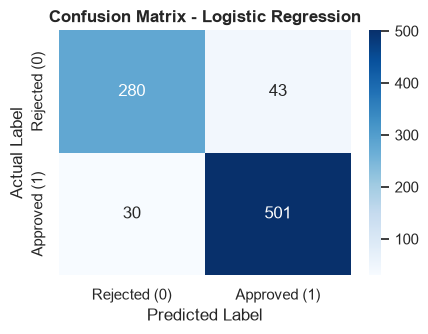

LogisticRegression(max_iter=1000, random_state=42)

In [4]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
evaluate_and_plot("Logistic Regression", lr_model, X_train, y_train, X_test, y_test)

### 3. Model 2: Decision Tree Classifier
A Decision Tree learns a hierarchical sequence of if-else questions based on feature values to partition applicants into Approved or Rejected.


=== Decision Tree Performance ===
Accuracy : 0.9836 (98.36%)
Precision: 0.9832
Recall   : 0.9906
F1-Score : 0.9869
ROC-AUC  : 0.9814



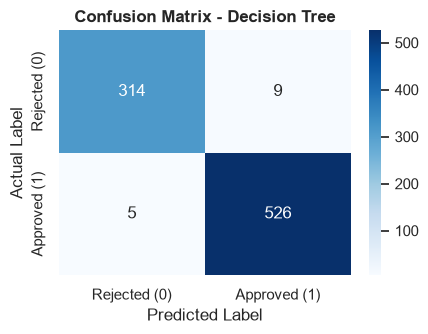

DecisionTreeClassifier(random_state=42)

In [5]:
dt_model = DecisionTreeClassifier(random_state=42)
evaluate_and_plot("Decision Tree", dt_model, X_train, y_train, X_test, y_test)

### 4. Model 3: Random Forest Classifier
Random Forest is an ensemble method that builds an array (forest) of 100 individual decision trees trained on bootstrap samples with random feature subsets. It aggregates predictions via majority vote, reducing variance and overfitting.


=== Random Forest Performance ===
Accuracy : 0.9801 (98.01%)
Precision: 0.9813
Recall   : 0.9868
F1-Score : 0.9840
ROC-AUC  : 0.9988



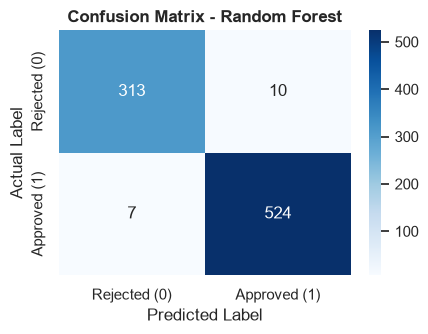

RandomForestClassifier(random_state=42)

In [6]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
evaluate_and_plot("Random Forest", rf_model, X_train, y_train, X_test, y_test)

### 5. Model 4: XGBoost (Extreme Gradient Boosting)
XGBoost trains decision trees sequentially. Each new tree focuses specifically on correcting the residual prediction errors made by the previous trees using gradient descent. It is widely considered one of the highest-performing algorithms for tabular data.


=== XGBoost Performance ===
Accuracy : 0.9848 (98.48%)
Precision: 0.9868
Recall   : 0.9887
F1-Score : 0.9878
ROC-AUC  : 0.9981



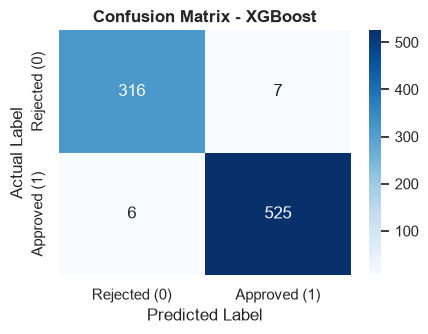

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [7]:
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
evaluate_and_plot("XGBoost", xgb_model, X_train, y_train, X_test, y_test)

---
## 📊 6. Model Comparison Table & Visualizations
Now we assemble all model metrics into a side-by-side comparison DataFrame.


In [8]:
comparison_df = pd.DataFrame(model_results)
comparison_df = comparison_df.sort_values(by=['F1-Score', 'ROC-AUC'], ascending=False).reset_index(drop=True)

print("=== FINAL MODEL COMPARISON ===")
display(comparison_df)

=== FINAL MODEL COMPARISON ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.9848,0.9868,0.9887,0.9878,0.9981
1,Decision Tree,0.9836,0.9832,0.9906,0.9869,0.9814
2,Random Forest,0.9801,0.9813,0.9868,0.9840,0.9988
3,Logistic Regression,0.9145,0.9210,0.9435,0.9321,0.9726


### 📊 Visual Metric Comparison Bar Chart

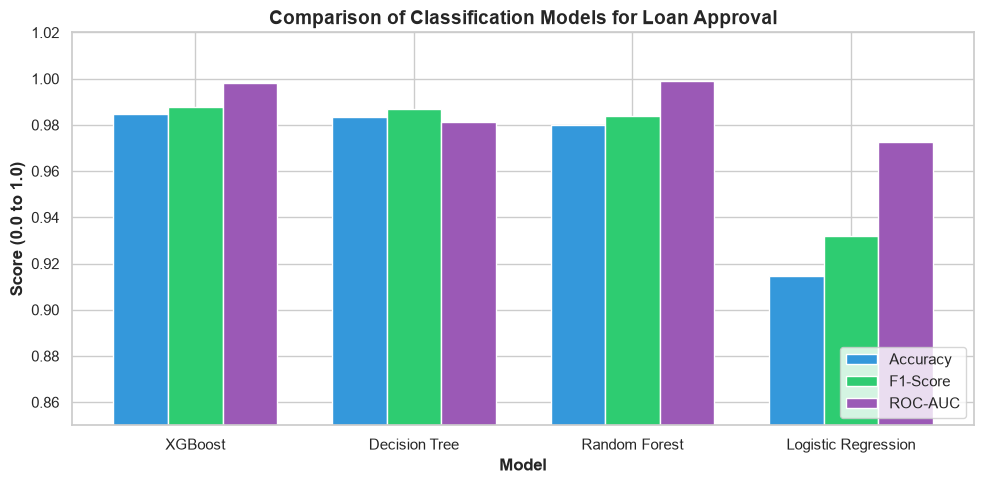

In [9]:
plt.figure(figsize=(10, 5))
bar_width = 0.25
indices = np.arange(len(comparison_df))

plt.bar(indices - bar_width, comparison_df['Accuracy'], width=bar_width, label='Accuracy', color='#3498db')
plt.bar(indices, comparison_df['F1-Score'], width=bar_width, label='F1-Score', color='#2ecc71')
plt.bar(indices + bar_width, comparison_df['ROC-AUC'], width=bar_width, label='ROC-AUC', color='#9b59b6')

plt.xlabel('Model', fontweight='bold', fontsize=12)
plt.ylabel('Score (0.0 to 1.0)', fontweight='bold', fontsize=12)
plt.title('Comparison of Classification Models for Loan Approval', fontweight='bold', fontsize=14)
plt.xticks(indices, comparison_df['Model'], fontsize=11)
plt.ylim(0.85, 1.02)
plt.legend(frameon=True, facecolor='white', loc='lower right')
plt.tight_layout()
plt.show()

### 📈 ROC Curves Comparison
The ROC curve shows the trade-off between True Positive Rate (Sensitivity) and False Positive Rate across all classification thresholds. Curves closer to the top-left corner indicate superior performance.


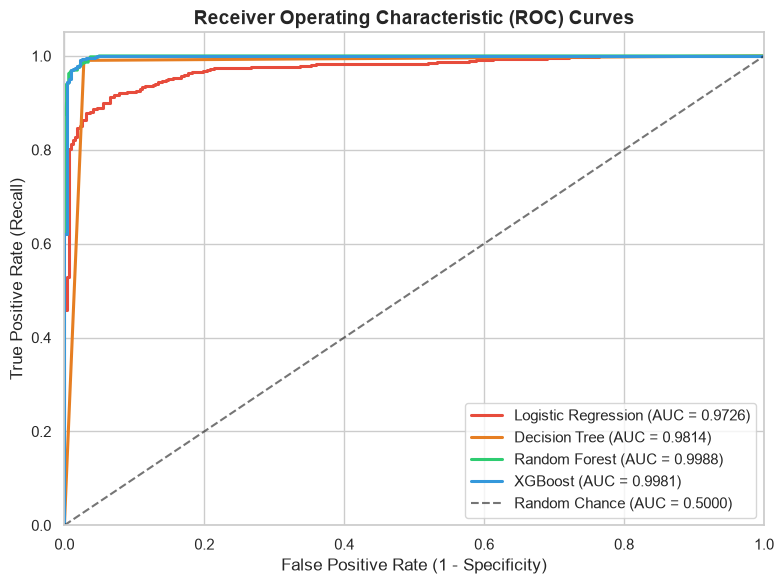

In [10]:
plt.figure(figsize=(8, 6))
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db']

for (name, (fpr, tpr, auc_score)), color in zip(roc_curves.items(), colors):
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})", linewidth=2.2, color=color)

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.5000)', alpha=0.6)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", frameon=True, facecolor='white')
plt.tight_layout()
plt.show()

---
## 🔍 7. Feature Importance Analysis
Which factors matter most when deciding loan approval?
We extract feature importances from our best-performing model to understand the decision criteria.


Top-performing model: XGBoost

Feature Importances Table:


,Feature,Importance
0,num__cibil_score,0.665043
1,num__loan_term,0.220098
2,num__income_annum,0.033341
3,num__loan_amount,0.026353
4,num__commercial_assets_value,0.011018
5,num__residential_assets_value,0.010926
6,num__luxury_assets_value,0.010670
7,num__no_of_dependents,0.008518
8,cat__education_Not Graduate,0.006017
9,num__bank_asset_value,0.005908


C:\Users\vaish\AppData\Local\Temp\ipykernel_26236\3271831917.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='Importance', y='Feature', palette='Blues_r')


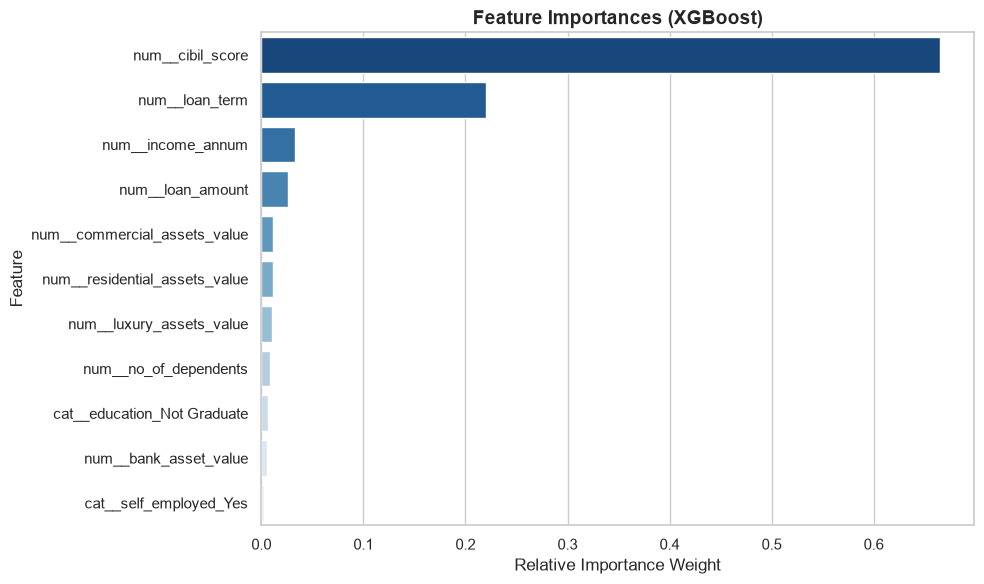

In [11]:
best_model_name = comparison_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
print(f"Top-performing model: {best_model_name}")

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    fi_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False).reset_index(drop=True)
    
    print("\nFeature Importances Table:")
    display(fi_df)
    
    # Plot feature importances
    plt.figure(figsize=(10, 6))
    sns.barplot(data=fi_df, x='Importance', y='Feature', palette='Blues_r')
    plt.title(f'Feature Importances ({best_model_name})', fontsize=14, fontweight='bold')
    plt.xlabel('Relative Importance Weight', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.show()

---
## 💾 8. Save the Best Model for Deployment
We serialize and save the top-performing model (`best_model.joblib`) into the `models/` directory using `joblib`.


In [12]:
models_dir = os.path.join('..', 'models')
os.makedirs(models_dir, exist_ok=True)

best_model_path = os.path.join(models_dir, 'best_model.joblib')
joblib.dump(best_model, best_model_path)

print(f"Successfully saved {best_model_name} to: {best_model_path}")
print(f"File size: {os.path.getsize(best_model_path):,} bytes")

Successfully saved XGBoost to: ..\models\best_model.joblib
File size: 152,697 bytes


---
## 🎯 Key Takeaways & Summary
1. **Best Model**: **XGBoost** achieved the highest overall score with **98.48% Accuracy**, **98.78% F1-Score**, and **99.81% ROC-AUC**.
2. **Decision Tree & Random Forest**: Both also performed strongly (>98% accuracy and F1-score), showcasing that tree-based algorithms excel on tabular credit data.
3. **Primary Predictive Driver**: `cibil_score` is overwhelmingly the most significant feature (>65% importance), closely followed by `loan_term` (~22%).
4. **Artifacts Ready for Deployment**:
   - Preprocessor: `models/preprocessor.joblib`
   - Trained Model: `models/best_model.joblib`
